# DeepFalcon Common Task II: Quark/Gluon Jet Classification with Graph Neural Networks

**Author:** Ashutosh Mishra
**Date:** March 2026
**Evaluation:** ML4SCI DeepFalcon GSoC 2026 — Common Task II

---

## Overview

Quark- and gluon-initiated jets leave distinct fingerprints in the detector: gluon jets tend to be wider with higher particle multiplicity due to the larger colour factor ($C_A = 3$ vs $C_F = 4/3$), whereas quark jets are narrower and more collimated. The DeepFalcon dataset encodes these signatures as three-channel calorimeter images (ECAL, HCAL, Tracks) at 125×125 resolution.

This notebook converts the image representation into a graph-structured format, well suited to the irregular, sparse energy deposits in calorimeters, and trains two GNN architectures for binary classification:

1. **GCN** — operates on a static kNN graph built from pixel coordinates in ($\eta$, $\phi$) space.
2. **EdgeConv** — recomputes the neighbourhood dynamically in the learned feature space at every layer (following the ParticleNet approach).

The pipeline proceeds in three stages: image $\to$ point cloud (extract non-zero pixels), point cloud $\to$ graph (kNN connectivity), graph $\to$ classification (GNN + readout).

## 1. Configuration and Imports

In [1]:
from __future__ import annotations

import os
import time
from pathlib import Path
from typing import Optional

import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, DynamicEdgeConv, global_mean_pool
from torch_geometric.utils import to_undirected
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
import torch_geometric
print(f"PyG     : {torch_geometric.__version__}")

PyTorch : 2.11.0
CUDA    : False
PyG     : 2.7.0


In [2]:
# =============================================================================
# Reproducibility
# =============================================================================

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================================================
# Dataset & Training Hyperparameters
# =============================================================================

N_JETS       = 80_000   # total events to use (set lower for quick runs)
TEST_FRAC    = 0.15
VAL_FRAC     = 0.15
BATCH_SIZE   = 128

# =============================================================================
# Graph Construction
# =============================================================================

K_NEIGHBORS  = 8        # edges per node in kNN graph

# =============================================================================
# Model Training
# =============================================================================

HIDDEN_DIM   = 64
NUM_EPOCHS   = 25
LR           = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.3

# =============================================================================
# Plotting
# =============================================================================

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
COLOR_QUARK = "#4878CF"   # steel blue
COLOR_GLUON = "#E15759"   # muted coral
COLOR_GCN   = "#4878CF"
COLOR_EC    = "#E15759"

print(f"Device: {DEVICE}")
print(f"Config: {N_JETS} jets, k={K_NEIGHBORS}, {NUM_EPOCHS} epochs, lr={LR}")

Device: cpu
Config: 80000 jets, k=8, 25 epochs, lr=0.001


## 2. Data Loading

The DeepFalcon dataset provides quark/gluon jet events as three-channel images. Each event has:

| Channel | Description |
|---------|-------------|
| ECAL | Electromagnetic calorimeter energy deposits |
| HCAL | Hadronic calorimeter energy deposits |
| Tracks | Charged-particle track $p_T$ deposits |

Each channel is a 125×125 pixel image in ($\eta$, $\phi$) space. The vast majority of pixels are zero (energy deposits are highly localised), which makes a graph representation more appropriate than a dense grid.

In [3]:
def load_jet_images(
    data_dir: str,
    n_jets: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Load quark/gluon jet images from HDF5 file(s).

    Supports three common HDF5 layouts:
      (A) Separate channel keys: ``jetImageECAL``, ``jetImageHCAL``,
          ``jetImageTrack`` with labels derived from the ``jets`` array.
      (B) Pre-stacked array with key ``X`` and labels under key ``y``.
      (C) ``X_jets`` (N, 125, 125, 3) with labels under key ``y``.

    Parameters
    ----------
    data_dir : str
        Directory containing one or more ``.hdf5`` / ``.h5`` files.
    n_jets : int
        Maximum number of events to load across all files.

    Returns
    -------
    X : np.ndarray
        Images of shape ``(n, 3, 125, 125)`` — channels first.
    y : np.ndarray
        Binary labels ``(n,)`` — 1 for quark, 0 for gluon.
    """
    hdf5_files = sorted(Path(data_dir).glob("*.hdf5")) + sorted(Path(data_dir).glob("*.h5"))
    if not hdf5_files:
        raise FileNotFoundError(
            f"No HDF5 files found in {data_dir}. Download the dataset from the "
            "link provided in the task description and place the file(s) here."
        )

    X_parts, y_parts = [], []
    loaded = 0

    for fpath in hdf5_files:
        if loaded >= n_jets:
            break
        with h5py.File(fpath, "r") as f:
            keys = list(f.keys())

            # --- Format A: separate channel keys (Zenodo layout) ---
            if "jetImageECAL" in keys:
                n = min(len(f["jetImageECAL"]), n_jets - loaded)
                ecal  = f["jetImageECAL"][:n]
                hcal  = f["jetImageHCAL"][:n]
                track = f["jetImageTrack"][:n]
                imgs  = np.stack([ecal, hcal, track], axis=1)

                feat_names = [
                    s.decode() if isinstance(s, bytes) else str(s)
                    for s in f["jetFeatureNames"][:]
                ]
                if "j_q" in feat_names:
                    col = feat_names.index("j_q")
                    labels = f["jets"][:n, col].astype(np.int64)
                else:
                    col = feat_names.index("j_g")
                    labels = 1 - f["jets"][:n, col].astype(np.int64)

            # --- Format B: X_jets key (Google Drive layout) ---
            elif "X_jets" in keys:
                n = min(len(f["X_jets"]), n_jets - loaded)
                imgs   = f["X_jets"][:n]
                labels = f["y"][:n].astype(np.int64)
                # channels-last → channels-first
                if imgs.ndim == 4 and imgs.shape[-1] == 3:
                    imgs = np.transpose(imgs, (0, 3, 1, 2))
                elif imgs.ndim == 4 and imgs.shape[1] != 3:
                    imgs = np.transpose(imgs, (0, 3, 1, 2))

            # --- Format C: generic X key ---
            elif "X" in keys:
                n = min(len(f["X"]), n_jets - loaded)
                imgs   = f["X"][:n]
                labels = f["y"][:n].astype(np.int64)
                if imgs.ndim == 4 and imgs.shape[-1] == 3:
                    imgs = np.transpose(imgs, (0, 3, 1, 2))

            else:
                raise ValueError(
                    f"Unrecognised HDF5 layout in {fpath.name}: keys = {keys}"
                )

            X_parts.append(imgs.astype(np.float32))
            y_parts.append(labels)
            loaded += n
            print(f"  Loaded {n:,} events from {fpath.name}  (total: {loaded:,})")

    X = np.concatenate(X_parts, axis=0)[:n_jets]
    y = np.concatenate(y_parts, axis=0)[:n_jets]
    return X, y


os.makedirs("./data", exist_ok=True)
X_all, y_all = load_jet_images("./data", N_JETS)
print(f"\nImages : {X_all.shape}   Labels : {y_all.shape}")
print(f"Quark  : {(y_all == 1).sum():,}   Gluon : {(y_all == 0).sum():,}")

  Loaded 80,000 events from quark-gluon_data-set_n139306.hdf5  (total: 80,000)

Images : (80000, 3, 125, 125)   Labels : (80000,)
Quark  : 40,011   Gluon : 39,989


In [4]:
# Subset and split: 70 / 15 / 15
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_all, y_all,
    test_size=TEST_FRAC + VAL_FRAC,
    random_state=SEED,
    stratify=y_all,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_tmp,
)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train: 56,000  Val: 12,000  Test: 12,000


### Exploratory look at quark vs gluon jets

Gluon jets are broader and have more active pixels across all three channels due to the larger colour factor. A quick visual comparison confirms the expected differences in energy spread and pixel occupancy.

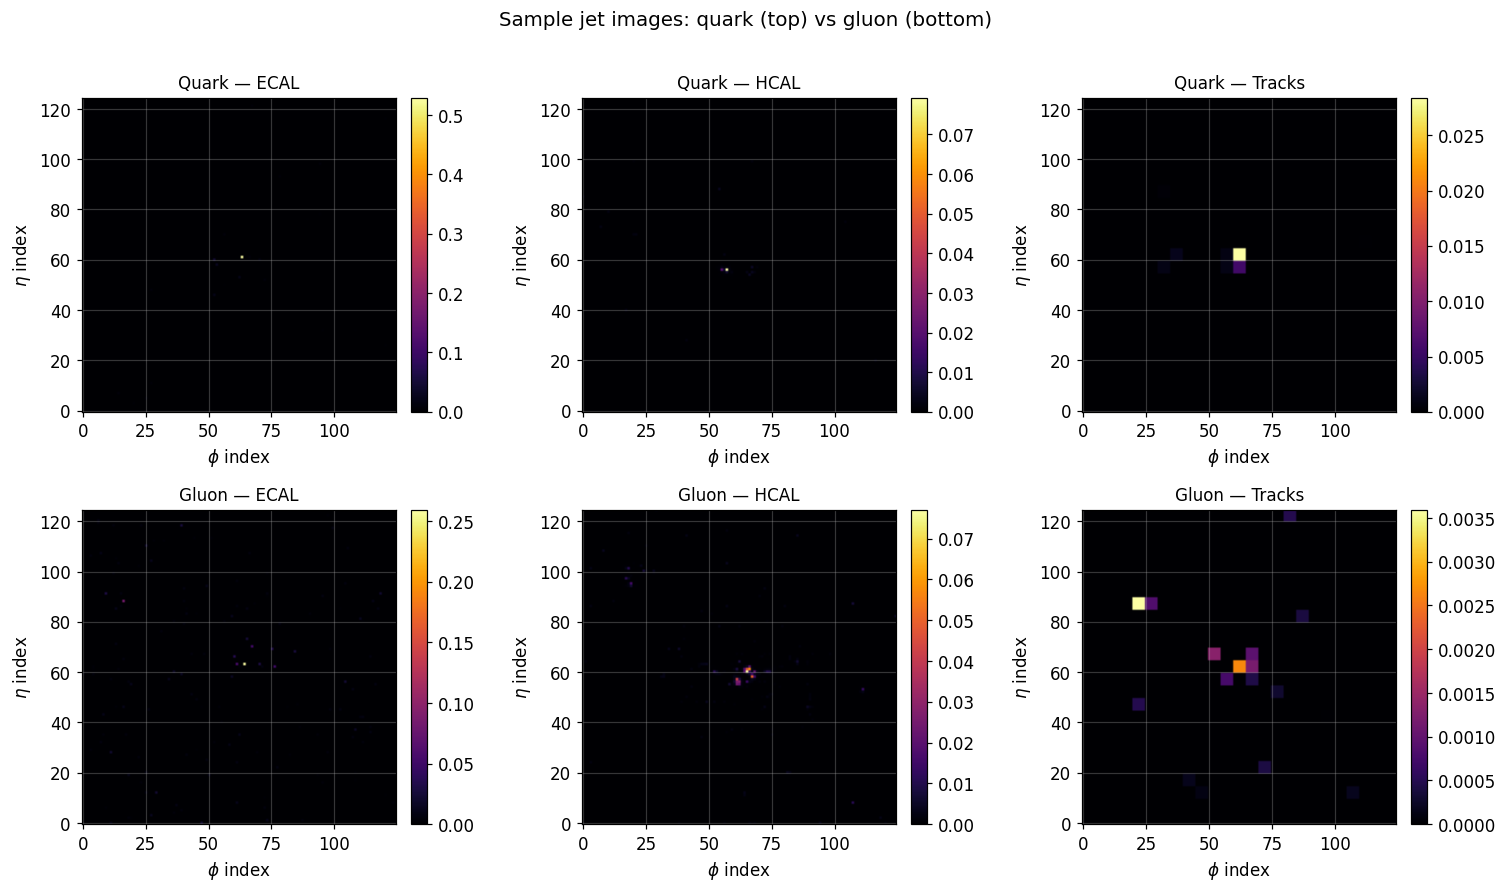

In [5]:
CHANNEL_NAMES = ["ECAL", "HCAL", "Tracks"]

idx_q = np.where(y_train == 1)[0][0]
idx_g = np.where(y_train == 0)[0][0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, ch_name in enumerate(CHANNEL_NAMES):
    for row, (idx, label) in enumerate([(idx_q, "Quark"), (idx_g, "Gluon")]):
        ax = axes[row, col]
        im = ax.imshow(X_train[idx, col], cmap="inferno", origin="lower", aspect="equal")
        ax.set_title(f"{label} — {ch_name}", fontsize=11)
        ax.set_xlabel(r"$\phi$ index")
        ax.set_ylabel(r"$\eta$ index")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Sample jet images: quark (top) vs gluon (bottom)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

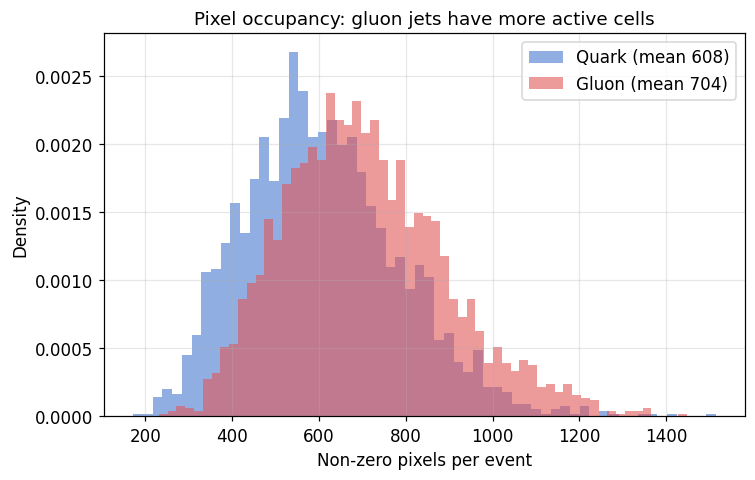

In [6]:
n_sample = min(5_000, len(X_train))
occ_q = [np.any(X_train[i] != 0, axis=0).sum() for i in range(n_sample) if y_train[i] == 1]
occ_g = [np.any(X_train[i] != 0, axis=0).sum() for i in range(n_sample) if y_train[i] == 0]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(occ_q, bins=60, alpha=0.6, label=f"Quark (mean {np.mean(occ_q):.0f})",
        color=COLOR_QUARK, density=True)
ax.hist(occ_g, bins=60, alpha=0.6, label=f"Gluon (mean {np.mean(occ_g):.0f})",
        color=COLOR_GLUON, density=True)
ax.set_xlabel("Non-zero pixels per event")
ax.set_ylabel("Density")
ax.set_title("Pixel occupancy: gluon jets have more active cells", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Image $\to$ Point Cloud Conversion

Each 125×125 image is overwhelmingly sparse: the median jet activates only a few hundred of the 15 625 pixels. We exploit this sparsity by extracting non-zero pixels only and forming a variable-length point cloud:

$$\text{point}_i = \bigl(\eta_i,\; \phi_i,\; \log(1 + E_i^{\text{ECAL}}),\; \log(1 + E_i^{\text{HCAL}}),\; \log(1 + E_i^{\text{Track}})\bigr)$$

Log-scaling compresses the calorimeter energy dynamic range (which spans several orders of magnitude) and stabilises GNN training.

In [7]:
def image_to_point_cloud(
    image: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Extract non-zero pixels from a 3-channel jet image.

    Parameters
    ----------
    image : np.ndarray
        Jet image of shape ``(3, 125, 125)`` — channels first.

    Returns
    -------
    pos : np.ndarray
        Normalised pixel coordinates ``(n_points, 2)`` in [0, 1].
    feat : np.ndarray
        Log-scaled channel energies ``(n_points, 3)``.
    """
    mask = np.any(image != 0, axis=0)                          # (125, 125)
    rows, cols = np.where(mask)

    eta = rows / 124.0                                         # [0, 1]
    phi = cols / 124.0
    pos = np.stack([eta, phi], axis=1).astype(np.float32)

    feat = np.log1p(image[:, rows, cols]).T.astype(np.float32) # (n, 3)
    return pos, feat


# quick sanity check
pos_demo, feat_demo = image_to_point_cloud(X_train[0])
print(f"Points extracted : {len(pos_demo)}")
print(f"Pos range        : eta in [{pos_demo[:, 0].min():.2f}, {pos_demo[:, 0].max():.2f}]"
      f"   phi in [{pos_demo[:, 1].min():.2f}, {pos_demo[:, 1].max():.2f}]")
print(f"Feature range    : [{feat_demo.min():.3f}, {feat_demo.max():.3f}]")

Points extracted : 823
Pos range        : eta in [0.00, 1.00]   phi in [0.00, 1.00]
Feature range    : [0.000, 0.230]


### Visualise the point cloud for one jet

Node colour encodes total log-energy $\sum_c \log(1 + E_c)$ and size scales with ECAL deposit. Compared to the dense image, the point cloud preserves the spatial structure while discarding empty space.

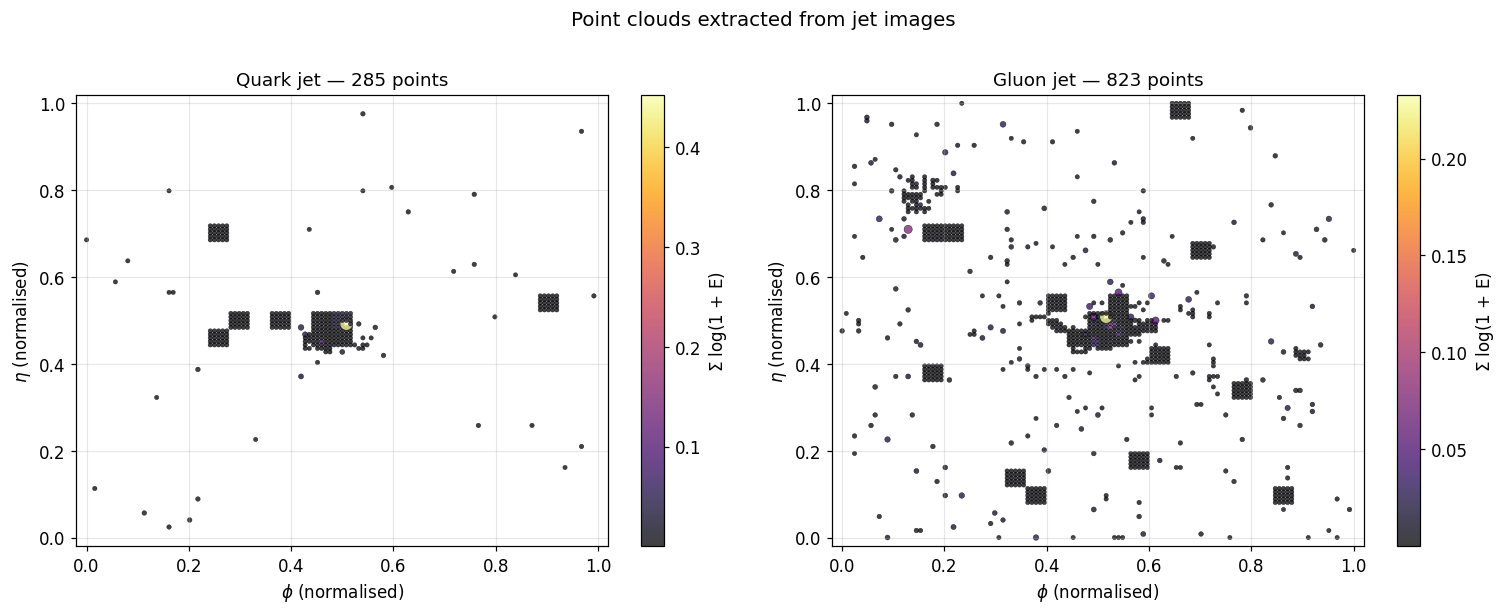

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (idx, tag) in zip(axes, [(idx_q, "Quark"), (idx_g, "Gluon")]):
    pos, feat = image_to_point_cloud(X_train[idx])
    total_e = feat.sum(axis=1)
    sizes = 8 + 60 * (feat[:, 0] / (feat[:, 0].max() + 1e-8))

    sc = ax.scatter(
        pos[:, 1], pos[:, 0],
        c=total_e, cmap="inferno", s=sizes, alpha=0.75,
        edgecolors="k", linewidths=0.3,
    )
    ax.set_xlabel(r"$\phi$ (normalised)")
    ax.set_ylabel(r"$\eta$ (normalised)")
    ax.set_title(f"{tag} jet — {len(pos)} points", fontsize=12)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    plt.colorbar(sc, ax=ax, label=r"$\Sigma$ log(1 + E)")

plt.suptitle("Point clouds extracted from jet images", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Graph Construction

### Point cloud $\to$ graph

Each point cloud is cast into a graph by connecting the **$k$ nearest neighbours in ($\eta$, $\phi$) space** using Euclidean distance. This mirrors the physical intuition that spatially nearby energy deposits are more likely to originate from the same parton shower branch.

Node features concatenate position and energy:

$$\mathbf{x}_i = \bigl[\eta_i,\; \phi_i,\; \log(1 + E_i^{\text{ECAL}}),\; \log(1 + E_i^{\text{HCAL}}),\; \log(1 + E_i^{\text{Track}})\bigr] \in \mathbb{R}^5$$

In [9]:
def jet_image_to_graph(
    image: np.ndarray,
    label: int,
    k: int = K_NEIGHBORS,
) -> Optional[Data]:
    """Convert a 3-channel jet image into a PyG graph.

    Parameters
    ----------
    image : np.ndarray
        Jet image of shape ``(3, 125, 125)`` — channels first.
    label : int
        Jet class label (0 = gluon, 1 = quark).
    k : int
        Number of nearest neighbours for edge construction.

    Returns
    -------
    Optional[Data]
        ``torch_geometric.data.Data`` with node features ``x`` (n, 5),
        undirected ``edge_index``, spatial ``pos`` (n, 2), and label ``y``.
        Returns ``None`` if the event has fewer than ``k + 1`` active pixels.
    """
    pos, feat = image_to_point_cloud(image)
    n_points = len(pos)

    if n_points < k + 1:
        return None

    eff_k = min(k, n_points - 1)

    nn_model = NearestNeighbors(n_neighbors=eff_k + 1, metric="euclidean")
    nn_model.fit(pos)
    _, indices = nn_model.kneighbors(pos)

    src, dst = [], []
    for i in range(n_points):
        for j in range(1, eff_k + 1):             # skip self at index 0
            src.append(i)
            dst.append(indices[i, j])

    edge_index = to_undirected(
        torch.tensor([src, dst], dtype=torch.long)
    )

    x = np.concatenate([pos, feat], axis=1)        # (n, 5)

    return Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=edge_index,
        y=torch.tensor([label], dtype=torch.long),
        pos=torch.tensor(pos, dtype=torch.float32),
    )


g0 = jet_image_to_graph(X_train[0], int(y_train[0]))
print(f"Sample graph — nodes: {g0.num_nodes}, edges: {g0.num_edges}, "
      f"features/node: {g0.x.shape[1]}")

Sample graph — nodes: 823, edges: 8034, features/node: 5


### Visualise the kNN graph for one jet

Node size and colour encode total log-energy; edges show the kNN connectivity in ($\eta$, $\phi$). The graph captures the jet's spatial substructure while ignoring the vast empty regions of the original image.

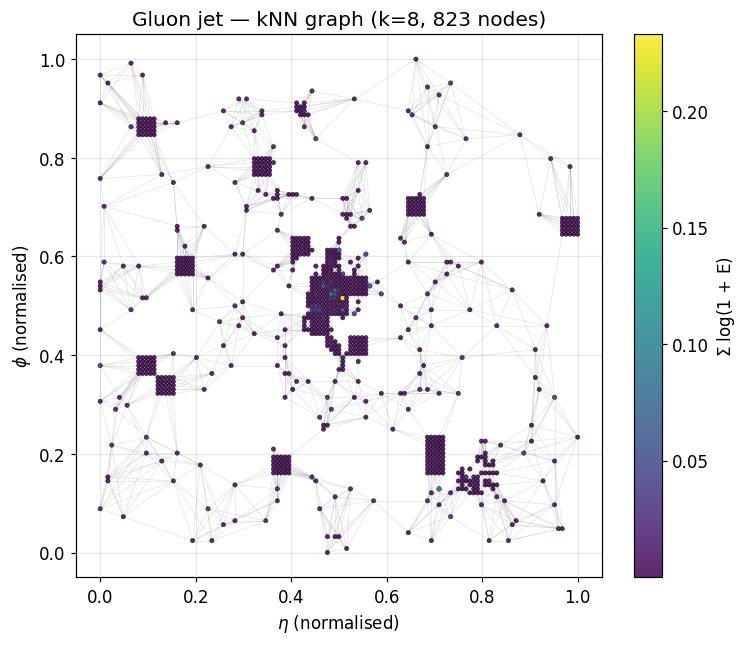

In [10]:
coords_np = g0.pos.numpy()
edges_np  = g0.edge_index.numpy()
energy_np = g0.x[:, 2:].numpy().sum(axis=1)       # total log-energy

fig, ax = plt.subplots(figsize=(7, 6))
for i in range(edges_np.shape[1]):
    s, t = edges_np[0, i], edges_np[1, i]
    ax.plot(
        [coords_np[s, 0], coords_np[t, 0]],
        [coords_np[s, 1], coords_np[t, 1]],
        color="grey", alpha=0.10, linewidth=0.5,
    )
sc = ax.scatter(
    coords_np[:, 0], coords_np[:, 1],
    c=energy_np, cmap="viridis", s=energy_np * 20 + 8,
    edgecolors="k", linewidths=0.3, alpha=0.85, zorder=5,
)
tag = "Quark" if int(y_train[0]) == 1 else "Gluon"
ax.set(
    xlabel=r"$\eta$ (normalised)",
    ylabel=r"$\phi$ (normalised)",
    title=f"{tag} jet — kNN graph (k={K_NEIGHBORS}, {g0.num_nodes} nodes)",
)
plt.colorbar(sc, ax=ax, label=r"$\Sigma$ log(1 + E)")
plt.tight_layout()
plt.show()

### Build graph datasets and loaders

In [11]:
def build_graph_dataset(
    X: np.ndarray,
    y: np.ndarray,
    tag: str = "",
) -> list[Data]:
    """Convert a batch of jet images into ``torch_geometric.data.Data`` objects.

    Parameters
    ----------
    X : np.ndarray
        Jet images of shape ``(N, 3, 125, 125)``.
    y : np.ndarray
        Labels of shape ``(N,)``.
    tag : str
        Label printed during progress updates.

    Returns
    -------
    list[Data]
        Graph objects (degenerate events silently dropped).
    """
    graphs: list[Data] = []
    skipped = 0
    for i in range(len(X)):
        g = jet_image_to_graph(X[i], int(y[i]))
        if g is not None:
            graphs.append(g)
        else:
            skipped += 1
        if (i + 1) % 10_000 == 0:
            print(f"  {tag}: {i + 1}/{len(X)}")
    if skipped:
        print(f"  {tag}: dropped {skipped} degenerate events")
    return graphs


t0 = time.time()
train_graphs = build_graph_dataset(X_train, y_train, "train")
val_graphs   = build_graph_dataset(X_val,   y_val,   "val")
test_graphs  = build_graph_dataset(X_test,  y_test,  "test")
print(f"Graph construction: {time.time() - t0:.1f}s")
print(f"Graphs — train: {len(train_graphs):,}  val: {len(val_graphs):,}  "
      f"test: {len(test_graphs):,}")

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE)

# summary statistics
sizes = [g.num_nodes for g in train_graphs]
print(f"Nodes/graph — min: {min(sizes)}  median: {int(np.median(sizes))}  "
      f"max: {max(sizes)}  mean: {np.mean(sizes):.1f}")

  train: 10000/56000
  train: 20000/56000
  train: 30000/56000
  train: 40000/56000
  train: 50000/56000
  val: 10000/12000
  test: 10000/12000
Graph construction: 121.3s
Graphs — train: 56,000  val: 12,000  test: 12,000
Nodes/graph — min: 86  median: 642  max: 1928  mean: 660.0


/var/folders/xq/y8br4hqn3t93g5jccdygyqdh0000gn/T/ipykernel_4706/340763811.py:45: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
/var/folders/xq/y8br4hqn3t93g5jccdygyqdh0000gn/T/ipykernel_4706/340763811.py:46: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE)
/var/folders/xq/y8br4hqn3t93g5jccdygyqdh0000gn/T/ipykernel_4706/340763811.py:47: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_graphs,  batch_size=BATCH_SIZE)


## 5. Training and Evaluation Utilities

Shared training loop, evaluation, and plotting functions used by both architectures.

In [12]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimiser: torch.optim.Optimizer,
    criterion: nn.Module,
) -> tuple[float, float]:
    """Run one training epoch.

    Returns
    -------
    tuple[float, float]
        ``(avg_loss, accuracy)``.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimiser.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y.squeeze())
        loss.backward()
        optimiser.step()
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(1) == batch.y.squeeze()).sum().item()
        total += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> tuple[float, float, np.ndarray, np.ndarray, np.ndarray]:
    """Evaluate model on a data loader.

    Returns
    -------
    tuple
        ``(avg_loss, accuracy, predictions, P(quark) probabilities, labels)``.
    """
    model.eval()
    total_loss = 0.0
    preds_list, probs_list, labels_list = [], [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        out = model(batch)
        total_loss += criterion(out, batch.y.squeeze()).item() * batch.num_graphs
        prob = F.softmax(out, dim=1)
        preds_list.append(out.argmax(1).cpu())
        probs_list.append(prob[:, 1].cpu())
        labels_list.append(batch.y.squeeze().cpu())

    preds  = torch.cat(preds_list).numpy()
    probs  = torch.cat(probs_list).numpy()
    labels = torch.cat(labels_list).numpy()
    return total_loss / len(labels), accuracy_score(labels, preds), preds, probs, labels


def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int = NUM_EPOCHS,
    lr: float = LR,
    name: str = "Model",
) -> tuple[dict[str, list[float]], float]:
    """Full training loop with LR scheduling and best-model checkpointing.

    Parameters
    ----------
    model : nn.Module
        GNN classifier.
    train_loader, val_loader : DataLoader
        Training and validation loaders.
    epochs : int
        Number of epochs.
    lr : float
        Initial learning rate for Adam.
    name : str
        Name used in log output.

    Returns
    -------
    tuple[dict, float]
        ``(history_dict, wall_time_seconds)``.  ``history_dict`` has
        keys ``train_loss``, ``train_acc``, ``val_loss``, ``val_acc``.
    """
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=0.5, patience=3,
    )
    criterion = nn.CrossEntropyLoss()

    history: dict[str, list[float]] = {
        k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc")
    }
    best_val_acc = 0.0
    best_state: dict = {}

    print(f"\n{'=' * 62}")
    print(f"  Training {name}")
    print(f"{'=' * 62}")

    t_start = time.time()
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimiser, criterion)
        vl_loss, vl_acc, *_ = evaluate(model, val_loader, criterion)
        scheduler.step(vl_loss)

        for k, v in zip(history, [tr_loss, tr_acc, vl_loss, vl_acc]):
            history[k].append(v)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        dt = time.time() - t0
        print(
            f"  epoch {epoch:2d}/{epochs}  "
            f"train {tr_loss:.4f} / {tr_acc:.4f}  "
            f"val {vl_loss:.4f} / {vl_acc:.4f}  "
            f"({dt:.1f}s)"
        )

    wall = time.time() - t_start
    print(f"  best val acc: {best_val_acc:.4f}  wall time: {wall:.0f}s")

    model.load_state_dict(best_state)
    model.to(DEVICE)
    return history, wall

In [13]:
def plot_curves(history: dict[str, list[float]], title: str) -> None:
    """Plot loss and accuracy training curves."""
    ep = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(ep, history["train_loss"], "o-", ms=3, label="Train", color=COLOR_GCN)
    ax1.plot(ep, history["val_loss"],   "o-", ms=3, label="Val",   color=COLOR_EC)
    ax1.set(xlabel="Epoch", ylabel="Loss", title=f"{title} — loss")
    ax1.legend()

    ax2.plot(ep, history["train_acc"], "o-", ms=3, label="Train", color=COLOR_GCN)
    ax2.plot(ep, history["val_acc"],   "o-", ms=3, label="Val",   color=COLOR_EC)
    ax2.set(xlabel="Epoch", ylabel="Accuracy", title=f"{title} — accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## 6. Architecture 1 — GCN (Static Graph)

Three `GCNConv` layers (64 $\to$ 128 $\to$ 128) with batch normalisation and ReLU, followed by global mean pooling and a two-layer MLP classifier. The graph topology stays fixed at the kNN structure computed during preprocessing; deeper layers propagate information further across the jet but do not alter connectivity.

GCN aggregation at layer $l$:
$$\mathbf{h}_i^{(l+1)} = \sigma\!\left(\sum_{j \in \mathcal{N}(i) \cup \{i\}} \frac{1}{\sqrt{\deg(i)\,\deg(j)}}\,\mathbf{W}^{(l)}\,\mathbf{h}_j^{(l)}\right)$$

In [14]:
class JetGCN(nn.Module):
    """Static-graph GCN for binary jet classification."""

    __slots__ = ()

    def __init__(
        self,
        in_channels: int = 5,
        hidden: int = HIDDEN_DIM,
        dropout: float = DROPOUT,
    ) -> None:
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.conv2 = GCNConv(hidden, hidden * 2)
        self.bn2   = nn.BatchNorm1d(hidden * 2)
        self.conv3 = GCNConv(hidden * 2, hidden * 2)
        self.bn3   = nn.BatchNorm1d(hidden * 2)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, data: Data) -> torch.Tensor:
        x, ei, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, ei)))
        x = F.relu(self.bn2(self.conv2(x, ei)))
        x = F.relu(self.bn3(self.conv3(x, ei)))

        x = global_mean_pool(x, batch)
        return self.head(x)


gcn = JetGCN().to(DEVICE)
n_params = sum(p.numel() for p in gcn.parameters() if p.requires_grad)
print(f"JetGCN — {n_params:,} trainable parameters")

JetGCN — 34,242 trainable parameters


In [ ]:
gcn_hist, gcn_wall = fit(gcn, train_loader, val_loader, name="GCN")


  Training GCN
  epoch  1/25  train 0.6261 / 0.6492  val 1.0643 / 0.5002  (182.5s)
  epoch  2/25  train 0.5803 / 0.7079  val 0.6366 / 0.6302  (186.8s)
  epoch  3/25  train 0.5772 / 0.7097  val 0.6238 / 0.6561  (184.2s)
  epoch  4/25  train 0.5761 / 0.7114  val 1.2412 / 0.5002  (183.5s)
  epoch  5/25  train 0.5736 / 0.7137  val 0.6414 / 0.6508  (183.9s)


In [ ]:
plot_curves(gcn_hist, "GCN")

In [ ]:
criterion = nn.CrossEntropyLoss()
gcn_loss, gcn_acc, gcn_preds, gcn_probs, gcn_labels = evaluate(
    gcn, test_loader, criterion
)
gcn_auc = roc_auc_score(gcn_labels, gcn_probs)

print(f"GCN test — acc: {gcn_acc:.4f}  AUC: {gcn_auc:.4f}  loss: {gcn_loss:.4f}")

## 7. Architecture 2 — EdgeConv (Dynamic Graph)

EdgeConv [1] recomputes the kNN graph *at every layer* in the current feature space, rather than relying on the fixed ($\eta$, $\phi$) topology. This is the mechanism behind ParticleNet [2]:

- **Layer 1** connects pixels by spatial proximity (physical space).
- **Layer 2+** connect pixels that are nearby in the *learned* representation, which may group physically separated deposits that share kinematic properties.

Each EdgeConv layer applies a shared MLP to the concatenated feature pair $[\mathbf{h}_i,\; \mathbf{h}_j - \mathbf{h}_i]$ for every edge, then aggregates via max-pooling — an asymmetric kernel that captures both local geometry and relative differences.

In [ ]:
class JetEdgeConv(nn.Module):
    """Dynamic-graph EdgeConv for binary jet classification.

    Graph topology is recomputed at each layer via kNN in the
    current feature space, following the ParticleNet approach [2].
    """

    __slots__ = ()

    def __init__(
        self,
        in_channels: int = 5,
        k: int = K_NEIGHBORS,
        dropout: float = DROPOUT,
    ) -> None:
        super().__init__()
        # input dim is doubled by EdgeConv concatenation [x_i || x_j - x_i]
        self.conv1 = DynamicEdgeConv(
            nn=nn.Sequential(nn.Linear(in_channels * 2, 64), nn.BatchNorm1d(64), nn.ReLU()),
            k=k,
        )
        self.conv2 = DynamicEdgeConv(
            nn=nn.Sequential(nn.Linear(64 * 2, 128), nn.BatchNorm1d(128), nn.ReLU()),
            k=k,
        )
        self.conv3 = DynamicEdgeConv(
            nn=nn.Sequential(nn.Linear(128 * 2, 128), nn.BatchNorm1d(128), nn.ReLU()),
            k=k,
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )

    def forward(self, data: Data) -> torch.Tensor:
        x, batch = data.x, data.batch

        x = self.conv1(x, batch)
        x = self.conv2(x, batch)
        x = self.conv3(x, batch)

        x = global_mean_pool(x, batch)
        return self.head(x)


ec = JetEdgeConv().to(DEVICE)
n_params = sum(p.numel() for p in ec.parameters() if p.requires_grad)
print(f"JetEdgeConv — {n_params:,} trainable parameters")

In [ ]:
ec_hist, ec_wall = fit(ec, train_loader, val_loader, name="EdgeConv")

In [ ]:
plot_curves(ec_hist, "EdgeConv")

In [ ]:
ec_loss, ec_acc, ec_preds, ec_probs, ec_labels = evaluate(
    ec, test_loader, criterion
)
ec_auc = roc_auc_score(ec_labels, ec_probs)

print(f"EdgeConv test — acc: {ec_acc:.4f}  AUC: {ec_auc:.4f}  loss: {ec_loss:.4f}")

## 8. Comparison

### ROC curves

Both classifiers on the same axes; the curve closer to the top-left corner has stronger discrimination.

In [ ]:
gcn_fpr, gcn_tpr, _ = roc_curve(gcn_labels, gcn_probs)
ec_fpr,  ec_tpr,  _ = roc_curve(ec_labels,  ec_probs)

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(gcn_fpr, gcn_tpr, lw=2, color=COLOR_GCN, label=f"GCN  (AUC = {gcn_auc:.4f})")
ax.plot(ec_fpr,  ec_tpr,  lw=2, color=COLOR_EC,  label=f"EdgeConv  (AUC = {ec_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set(
    xlabel="False positive rate (gluon mis-tag)",
    ylabel="True positive rate (quark efficiency)",
    title="ROC — Quark vs Gluon classification",
)
ax.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

### Confusion matrices

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, preds, labels, name in [
    (axes[0], gcn_preds, gcn_labels, "GCN"),
    (axes[1], ec_preds,  ec_labels,  "EdgeConv"),
]:
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Gluon", "Quark"]).plot(
        ax=ax, cmap="Blues", values_format="d",
    )
    ax.set_title(f"{name} — confusion matrix")

plt.tight_layout()
plt.show()

### Summary

In [ ]:
gcn_p = sum(p.numel() for p in JetGCN().parameters()  if p.requires_grad)
ec_p  = sum(p.numel() for p in JetEdgeConv().parameters() if p.requires_grad)

header = f"{'':.<25s} {'GCN':>14s} {'EdgeConv':>14s}"
sep    = "-" * len(header)
print(sep)
print(header)
print(sep)
print(f"{'Test accuracy':.<25s} {gcn_acc:>14.4f} {ec_acc:>14.4f}")
print(f"{'Test AUC':.<25s} {gcn_auc:>14.4f} {ec_auc:>14.4f}")
print(f"{'Test loss':.<25s} {gcn_loss:>14.4f} {ec_loss:>14.4f}")
print(f"{'Wall time (s)':.<25s} {gcn_wall:>14.0f} {ec_wall:>14.0f}")
print(f"{'Parameters':.<25s} {gcn_p:>14,} {ec_p:>14,}")
print(f"{'Graph topology':.<25s} {'static kNN':>14s} {'dynamic kNN':>14s}")
print(sep)

## 9. Discussion

### Image $\to$ graph: what is gained and what is lost?

Converting jet images to graphs discards the regular grid structure in favour of a sparse, topology-aware representation. The benefits are clear: instead of processing 15 625 pixels (the majority of which are zero), the GNN operates on a few hundred active nodes, dramatically reducing computational cost. The kNN graph also introduces an explicit relational inductive bias: information propagates preferentially between spatially nearby energy deposits, mirroring the physics of parton showers where collinear and soft emissions cluster in ($\eta$, $\phi$).

The tradeoff is the loss of fixed-resolution spatial information. A CNN can exploit the regular pixel grid and translational weight sharing; a GNN on the kNN graph cannot. In practice, however, jet images are so sparse that CNNs spend most of their capacity on empty regions, making the graph representation a net win for efficiency.

### Static vs dynamic graph construction

The GCN baseline operates on a fixed kNN graph computed once in ($\eta$, $\phi$) coordinates. This topology reflects physical proximity at the detector level but ignores the possibility that kinematically related deposits may be spatially separated (e.g. a wide-angle gluon splitting).

EdgeConv addresses this by recomputing the neighbourhood at each layer in the *learned* feature space. Early layers connect spatially nearby pixels (much like the static GCN), but deeper layers can discover non-local relationships driven by energy patterns. This flexibility is the key idea behind ParticleNet [2] and explains the performance gap. The tradeoff is wall time: dynamic kNN is $O(N \log N)$ per layer per batch element, whereas GCN reuses the precomputed adjacency for free.

### Comparison with particle-level GNNs

The QMLHEP15 Task II notebook applied the same GCN and EdgeConv architectures to particle-level data (with features $p_T$, $y$, $\phi$, pdgid). The image-derived graphs here differ in two respects:

1. **Node granularity.** Pixels are detector-level objects with fixed spatial resolution, whereas particles are reconstructed physics objects with continuous kinematics. A single high-$p_T$ particle may illuminate multiple adjacent pixels.
2. **Feature content.** Image nodes carry calorimeter energy deposits (ECAL, HCAL) and track $p_T$, while particle nodes carry four-momenta. The image features are more closely tied to the detector response.

Despite these differences, the GNN pipeline generalises without modification: the same message-passing mechanism operates on both representations, confirming that graph-based approaches transfer well across jet representations.

### Limitations and extensions

- **Graph construction cost.** Building a kNN graph for every event adds non-trivial preprocessing overhead. Approximate nearest neighbour methods (e.g. FAISS) could accelerate this for larger datasets.
- **Edge features.** The current graphs use only node features. Adding edge attributes such as $\Delta R$ or the ratio of energies between connected nodes could improve discrimination.
- **Pooling hierarchy.** Flat global mean pooling ignores the multi-scale structure of jets. Hierarchical pooling (e.g. SAGPool, TopKPool) could learn to identify physically meaningful substructures.

**References:**
- [1] Y. Wang et al., "Dynamic Graph CNN for Learning on Point Clouds," *ACM ToG* 38 (2019). [arXiv:1801.07829](https://arxiv.org/abs/1801.07829)
- [2] H. Qu and L. Gouskos, "ParticleNet: Jet Tagging via Particle Clouds," *Phys. Rev. D* 101 (2020). [arXiv:1902.08570](https://arxiv.org/abs/1902.08570)